# TTC Multi-Year Bus Delay Analysis

This notebook loads all TTC bus delay datasets in the `data/` folder, standardizes mixed schemas across years, and produces yearly, monthly, weekly, and incident-level summaries.

Run all cells. By default, it scans every `.csv` file in `../data` and skips the readme/metadata file.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = Path('../data')
FILE_PATTERN = '*.csv'
EXCLUDED_TOKENS = ('readme',)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')


In [2]:
COLUMN_ALIASES = {
    'date': 'date',
    'report_date': 'date',
    'incident_date': 'date',
    'time': 'time',
    'report_time': 'time',
    'incident_time': 'time',
    'time_of_day': 'time',
    'route': 'route',
    'route_number': 'route',
    'route_name': 'route',
    'route_no': 'route',
    'route_num': 'route',
    'line': 'route',
    'station': 'location',
    'location': 'location',
    'location_name': 'location',
    'intersection': 'location',
    'incident': 'incident',
    'incident_type': 'incident',
    'incident_description': 'incident',
    'delay_reason': 'incident',
    'code': 'incident_code',
    'min_delay': 'min_delay',
    'min delay': 'min_delay',
    'delay_minutes': 'min_delay',
    'delay': 'min_delay',
    'min_gap': 'min_gap',
    'min gap': 'min_gap',
    'gap_minutes': 'min_gap',
    'gap': 'min_gap',
    'day': 'day',
    'direction': 'direction',
    'bound': 'direction',
    'vehicle': 'vehicle',
}

REQUIRED_COLUMNS = ['date', 'time', 'route', 'location', 'min_delay', 'min_gap']

def normalize_col(col: str) -> str:
    col = str(col).strip().strip('\"').replace('﻿', '').replace('​', '')
    col = col.replace('/', '_').replace('-', '_').lower()
    col = re.sub(r'[^a-z0-9_]+', '_', col)
    col = re.sub(r'_+', '_', col).strip('_')
    return COLUMN_ALIASES.get(col, col)

def read_any_table(file_path: Path) -> pd.DataFrame:
    payload = file_path.read_bytes()
    is_excel_payload = payload[:2] == b'PK'

    if file_path.suffix.lower() in {'.xlsx', '.xls'} or is_excel_payload:
        return pd.read_excel(file_path)

    encodings = ('utf-8', 'utf-8-sig', 'utf-16', 'cp1252', 'latin1')
    separators = (None, ',', '\t', ';', '|')

    for encoding in encodings:
        for separator in separators:
            try:
                return pd.read_csv(file_path, encoding=encoding, sep=separator, engine='python', on_bad_lines='skip')
            except Exception:
                pass

    raise ValueError(f'Unable to parse file: {file_path}')

def categorize_incident(text: str) -> str:
    value = str(text).strip().lower()
    if not value or value == 'nan':
        return 'Unknown'

    keyword_map = {
        'Mechanical': ['mechanical', 'engine', 'brake', 'vehicle', 'equipment'],
        'Traffic': ['traffic', 'congestion', 'slow traffic'],
        'Security': ['security', 'police', 'investigation'],
        'Diversion': ['diversion', 'detour', 'road closure'],
        'Collision': ['collision', 'accident', 'crash'],
        'Medical': ['medical', 'sick customer', 'injury'],
        'Weather': ['weather', 'snow', 'storm', 'rain'],
        'Passenger': ['passenger', 'customer', 'wheelchair'],
        'Operations': ['operator', 'crew', 'dispatch', 'late leaving', 'general delay'],
        'Construction': ['construction', 'work zone'],
    }

    for label, keywords in keyword_map.items():
        if any(keyword in value for keyword in keywords):
            return label

    if re.fullmatch(r'[A-Z]{4,6}', str(text).strip()):
        return f'Code-{str(text).strip()[:2]}'

    return str(text).strip().title()

def standardize_dataset(df: pd.DataFrame, file_path: Path) -> pd.DataFrame:
    df = df.copy()
    df.columns = [normalize_col(column) for column in df.columns]

    for target, patterns in {
        'date': ('date',),
        'time': ('time',),
        'route': ('route', 'line'),
        'location': ('location', 'station', 'intersection', 'stop'),
        'incident': ('incident',),
        'incident_code': ('code',),
        'min_delay': ('delay',),
        'min_gap': ('gap',),
        'direction': ('direction', 'bound'),
    }.items():
        if target in df.columns:
            continue
        match = next((col for col in df.columns if any(pattern in col for pattern in patterns)), None)
        if match is not None:
            df[target] = df[match]

    if 'min_gap' not in df.columns and 'min_delay' in df.columns:
        df['min_gap'] = df['min_delay']

    missing = [column for column in REQUIRED_COLUMNS if column not in df.columns]
    if missing:
        raise ValueError(f'{file_path.name} is missing required columns: {missing}')

    if 'incident' not in df.columns and 'incident_code' in df.columns:
        df['incident'] = df['incident_code']

    if 'incident_code' not in df.columns:
        df['incident_code'] = pd.NA

    standardized = pd.DataFrame()
    standardized['date'] = pd.to_datetime(df['date'], errors='coerce')
    standardized['time'] = df['time'].astype(str).str.strip()
    standardized['route'] = df['route'].astype(str).str.strip()
    standardized['location'] = df['location'].astype(str).str.strip()
    standardized['incident'] = df['incident'].astype(str).str.strip()
    standardized['incident_code'] = df['incident_code'].astype(str).str.strip()
    standardized['min_delay'] = pd.to_numeric(df['min_delay'], errors='coerce')
    standardized['min_gap'] = pd.to_numeric(df['min_gap'], errors='coerce')
    standardized['direction'] = df['direction'].astype(str).str.strip() if 'direction' in df.columns else pd.NA
    standardized['vehicle'] = df['vehicle'] if 'vehicle' in df.columns else pd.NA
    standardized['source_file'] = file_path.name

    standardized = standardized.dropna(subset=['date'])
    standardized['year'] = standardized['date'].dt.year
    standardized['month'] = standardized['date'].dt.month
    standardized['month_name'] = standardized['date'].dt.month_name().str.slice(0, 3)
    standardized['week'] = standardized['date'].dt.isocalendar().week.astype('int64')
    standardized['day_name'] = standardized['date'].dt.day_name()
    standardized['quarter'] = standardized['date'].dt.quarter
    standardized['incident_category'] = standardized['incident'].apply(categorize_incident)

    return standardized

def load_all_datasets(data_dir: Path):
    files = sorted(path for path in data_dir.glob(FILE_PATTERN) if not any(token in path.name.lower() for token in EXCLUDED_TOKENS))

    frames = []
    file_summary_rows = []
    failures = []

    for file_path in files:
        try:
            raw = read_any_table(file_path)
            clean = standardize_dataset(raw, file_path)
            frames.append(clean)
            file_summary_rows.append({
                'file_name': file_path.name,
                'rows_loaded': len(clean),
                'min_year': clean['year'].min(),
                'max_year': clean['year'].max(),
            })
        except Exception as exc:
            failures.append((file_path.name, str(exc)))

    if not frames:
        raise ValueError('No usable dataset files were loaded from the data directory.')

    combined = pd.concat(frames, ignore_index=True)
    file_summary = pd.DataFrame(file_summary_rows).sort_values(['min_year', 'file_name']).reset_index(drop=True)
    return combined, file_summary, failures


In [3]:
df, file_summary, failures = load_all_datasets(DATA_DIR)

print(f'Total rows loaded: {len(df):,}')
print(f'Years covered: {int(df["year"].min())} to {int(df["year"].max())}')
print(f'Files loaded: {len(file_summary):,}')
print(f'Files skipped due to parsing/shape issues: {len(failures):,}')

display(file_summary.head(20))
if failures:
    display(pd.DataFrame(failures, columns=['file_name', 'error']))


Total rows loaded: 776,435
Years covered: 2014 to 2026
Files loaded: 100
Files skipped due to parsing/shape issues: 1


,file_name,rows_loaded,min_year,max_year
0,ttc-bus-delay-data-2014__01_Jan_2014.csv,9822,2014,2014
1,ttc-bus-delay-data-2014__02_Feb_2014.csv,8115,2014,2014
2,ttc-bus-delay-data-2014__03_Mar_2014.csv,8127,2014,2014
3,ttc-bus-delay-data-2014__04_Apr_2014.csv,7881,2014,2014
4,ttc-bus-delay-data-2014__05_May_2014.csv,8030,2014,2014
5,ttc-bus-delay-data-2014__06_June_2014.csv,7834,2014,2014
6,ttc-bus-delay-data-2014__07_July_2014.csv,6661,2014,2014
7,ttc-bus-delay-data-2014__08_Aug_2014.csv,6654,2014,2014
8,ttc-bus-delay-data-2014__09_Sept_2014.csv,8746,2014,2014
9,ttc-bus-delay-data-2014__10_Oct_2014.csv,7979,2014,2014


,file_name,error
0,Code Descriptions.csv,Code Descriptions.csv is missing required colu...


In [4]:
quality_table = pd.DataFrame({
    'missing_count': df[['date', 'time', 'route', 'location', 'incident', 'min_delay', 'min_gap']].isna().sum(),
})
quality_table['missing_pct'] = (100 * quality_table['missing_count'] / len(df)).round(2)

display(quality_table)
display(df[['min_delay', 'min_gap']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


,missing_count,missing_pct
date,0,0.00
time,0,0.00
route,0,0.00
location,0,0.00
incident,0,0.00
min_delay,464,0.06
min_gap,944,0.12


,min_delay,min_gap
count,775971.000000,775491.000000
mean,20.226341,30.872157
std,286.881123,66.017896
min,-54.000000,-2.000000
50%,10.000000,20.000000
75%,17.000000,32.000000
90%,26.000000,48.000000
95%,32.000000,60.000000
99%,235.000000,255.000000
max,246245.000000,6528.000000


,year,events,total_delay,avg_delay
0,2014,94217,1650366.0,17.520367
1,2015,76510,1308682.0,17.105389
2,2016,77088,1383240.0,17.944114
3,2017,70303,1364758.0,19.414447
4,2018,73927,2056619.0,27.865956
5,2019,62376,1375487.0,22.141705
6,2020,36151,741525.0,20.543135
7,2021,42269,799450.0,18.913388
8,2022,58707,1180912.0,20.115353
9,2023,56207,1138282.0,20.251606


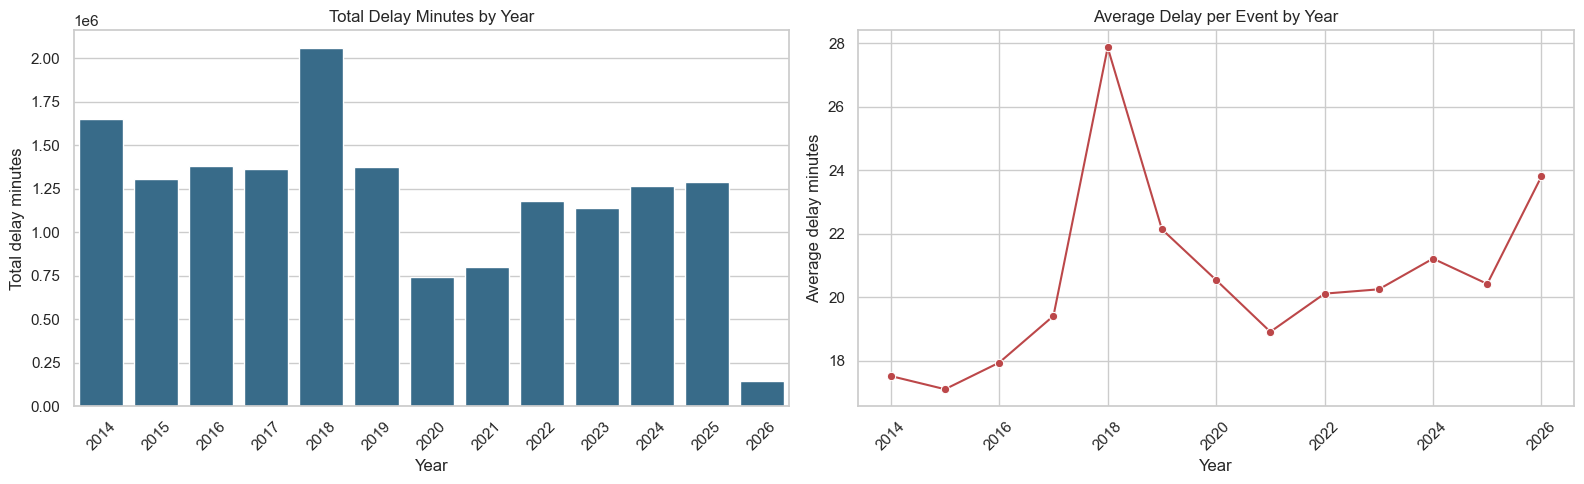

In [5]:
yearly = (
    df.groupby('year', as_index=False)
      .agg(events=('year', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('year')
)

display(yearly)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=yearly, x='year', y='total_delay', ax=axes[0], color='#2a6f97')
axes[0].set_title('Total Delay Minutes by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total delay minutes')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=yearly, x='year', y='avg_delay', marker='o', ax=axes[1], color='#bc4749')
axes[1].set_title('Average Delay per Event by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average delay minutes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


,year,month,events,total_delay,avg_delay
0,2014,1,9822,124223.0,12.651288
1,2014,2,8115,131071.0,16.153685
2,2014,3,8127,368890.0,45.413025
3,2014,4,7881,93791.0,11.905433
4,2014,5,8030,114173.0,14.221849
5,2014,6,7834,117031.0,14.948397
6,2014,7,6661,115752.0,17.380180
7,2014,8,6654,114827.0,17.256838
8,2014,9,8746,125476.0,14.348313
9,2014,10,7979,125268.0,15.699712


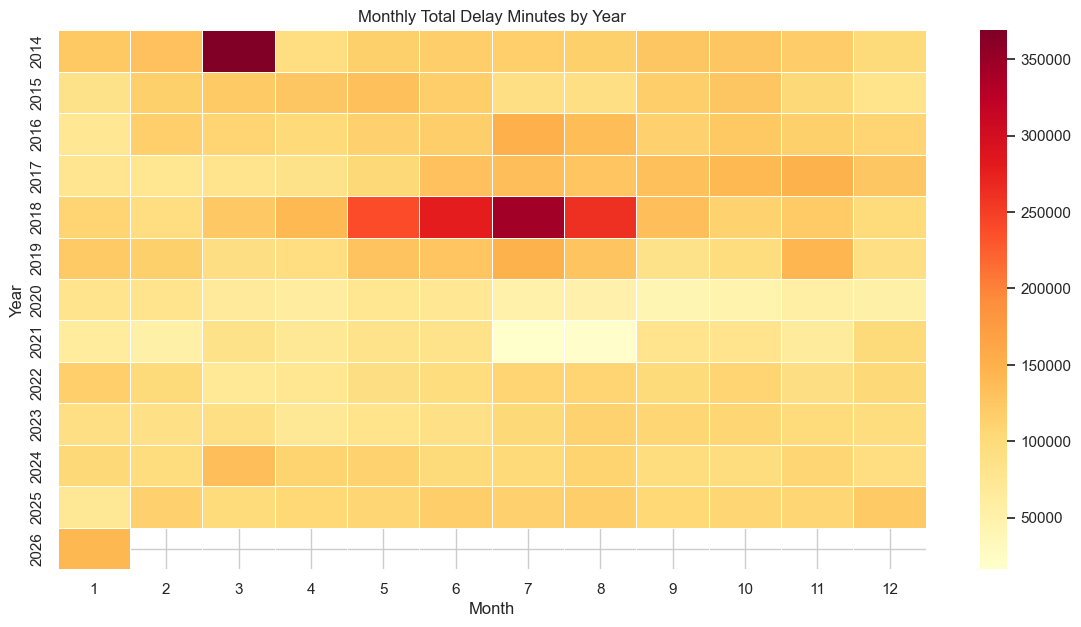

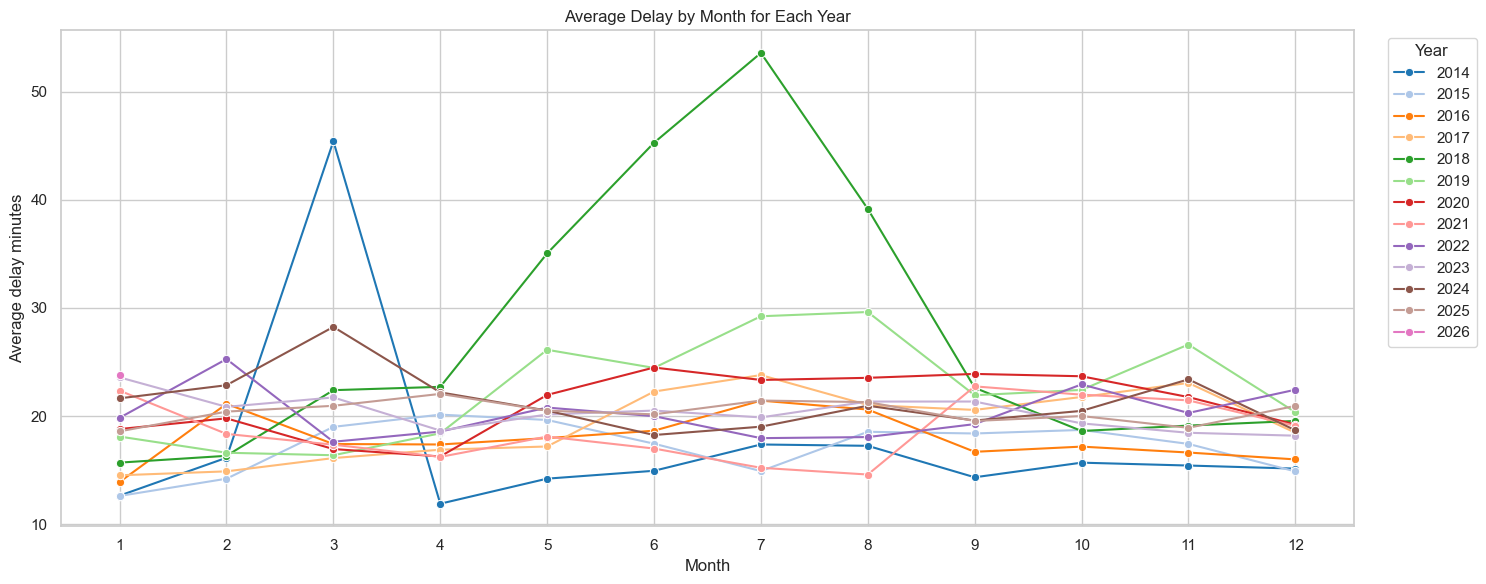

In [6]:
monthly = (
    df.groupby(['year', 'month'], as_index=False)
      .agg(events=('month', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values(['year', 'month'])
)

month_heatmap = monthly.pivot(index='year', columns='month', values='total_delay').sort_index()

display(monthly.head(24))

plt.figure(figsize=(14, 7))
sns.heatmap(month_heatmap, cmap='YlOrRd', linewidths=0.5, linecolor='white')
plt.title('Monthly Total Delay Minutes by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly, x='month', y='avg_delay', hue='year', marker='o', palette='tab20')
plt.title('Average Delay by Month for Each Year')
plt.xlabel('Month')
plt.ylabel('Average delay minutes')
plt.xticks(range(1, 13))
plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


,year,week,events,total_delay,avg_delay
0,2014,1,2078,27661.0,13.311357
1,2014,2,2510,30686.0,12.230371
2,2014,3,1635,21237.0,12.996940
3,2014,4,2280,26104.0,11.449123
4,2014,5,2315,33625.0,14.531115
5,2014,6,2354,43107.0,18.320017
6,2014,7,2006,27223.0,13.570788
7,2014,8,1801,35654.0,19.796780
8,2014,9,1950,269723.0,138.390457
9,2014,10,1980,30423.0,15.365152


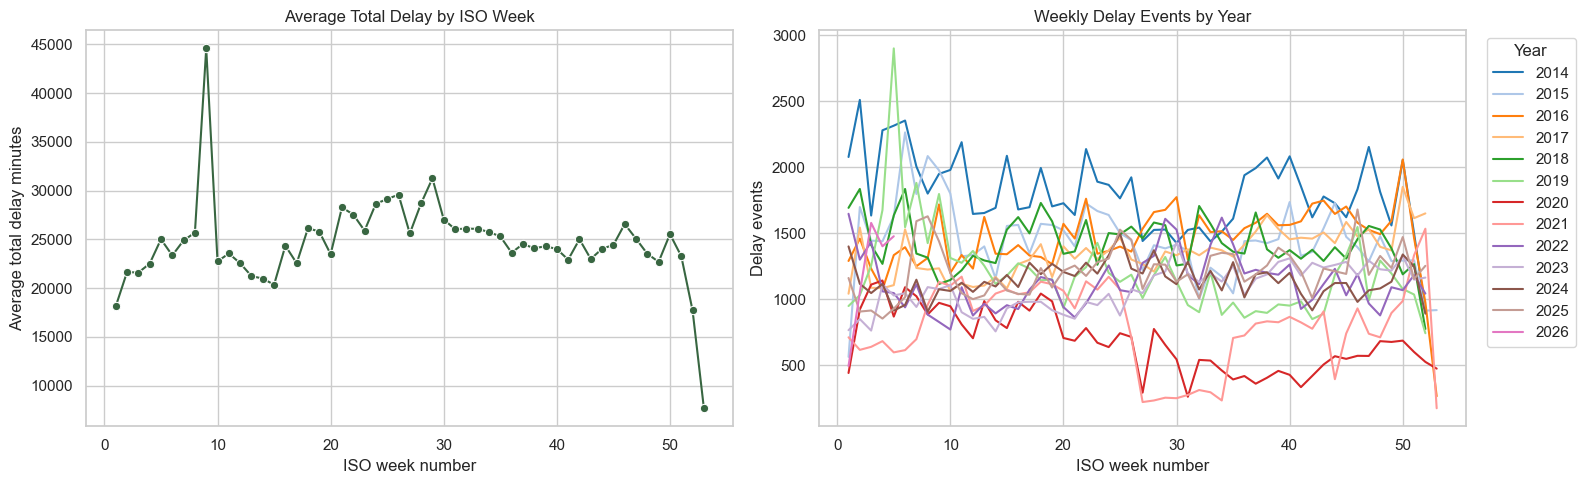

In [7]:
weekly = (
    df.groupby(['year', 'week'], as_index=False)
      .agg(events=('week', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values(['year', 'week'])
)

weekly_profile = (
    weekly.groupby('week', as_index=False)
          .agg(avg_events=('events', 'mean'), avg_total_delay=('total_delay', 'mean'), avg_delay=('avg_delay', 'mean'))
)

display(weekly.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=weekly_profile, x='week', y='avg_total_delay', marker='o', ax=axes[0], color='#386641')
axes[0].set_title('Average Total Delay by ISO Week')
axes[0].set_xlabel('ISO week number')
axes[0].set_ylabel('Average total delay minutes')

sns.lineplot(data=weekly, x='week', y='events', hue='year', palette='tab20', ax=axes[1])
axes[1].set_title('Weekly Delay Events by Year')
axes[1].set_xlabel('ISO week number')
axes[1].set_ylabel('Delay events')
axes[1].legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


,incident,events,total_delay,avg_delay
5,Diversion,40409,5795947.0,143.905725
54,Mechanical,247737,2958192.0,11.943508
15,General Delay,79177,1454672.0,18.389826
85,Utilized Off Route,87023,771323.0,8.874963
56,Operations - Operator,51266,745243.0,14.536789
21,Late Leaving Garage,65450,677129.0,10.350964
17,Investigation,50993,640124.0,12.558099
27,MFDV,4814,564047.0,117.168052
14,Emergency Services,21260,257902.0,12.131997
76,Security,16765,203378.0,12.131106


,incident_category,events,total_delay,avg_delay
14,Diversion,40409,5795947.0,143.905725
26,Mechanical,249605,2977672.0,11.932883
31,Operations,199389,2907200.0,14.589763
36,Security,67758,843502.0,12.452420
4,Code-MF,22662,806082.0,35.569764
42,Utilized Off Route,87023,771323.0,8.874963
13,Collision,17535,365673.0,20.853892
20,Emergency Services,21260,257902.0,12.131997
18,Efo,14713,201098.0,13.668049
11,Code-TF,13076,174447.0,13.341006


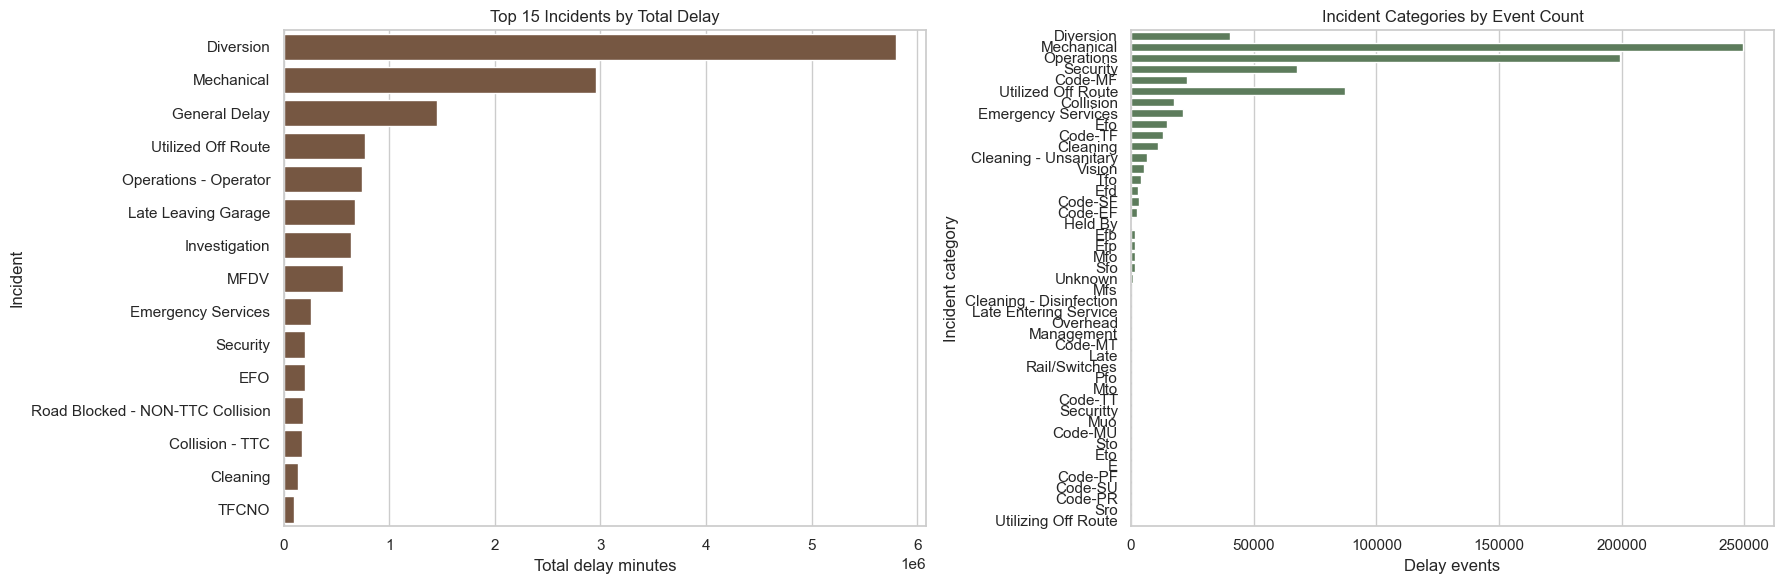

In [8]:
top_incidents = (
    df.groupby('incident', as_index=False)
      .agg(events=('incident', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
      .head(15)
)

incident_categories = (
    df.groupby('incident_category', as_index=False)
      .agg(events=('incident_category', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
)

display(top_incidents)
display(incident_categories)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=top_incidents, y='incident', x='total_delay', ax=axes[0], color='#7f5539')
axes[0].set_title('Top 15 Incidents by Total Delay')
axes[0].set_xlabel('Total delay minutes')
axes[0].set_ylabel('Incident')

sns.barplot(data=incident_categories, y='incident_category', x='events', ax=axes[1], color='#588157')
axes[1].set_title('Incident Categories by Event Count')
axes[1].set_xlabel('Delay events')
axes[1].set_ylabel('Incident category')

plt.tight_layout()
plt.show()


,year,incident_category,events,total_delay
0,2014,Diversion,3699,650333.0
1,2014,Emergency Services,1431,17883.0
2,2014,Mechanical,43047,466289.0
3,2014,Operations,25363,320376.0
4,2014,Security,7019,82763.0
5,2014,Utilized Off Route,13658,112722.0
6,2015,Diversion,4160,501467.0
7,2015,Emergency Services,1337,17256.0
8,2015,Mechanical,30586,346435.0
9,2015,Operations,22127,277057.0


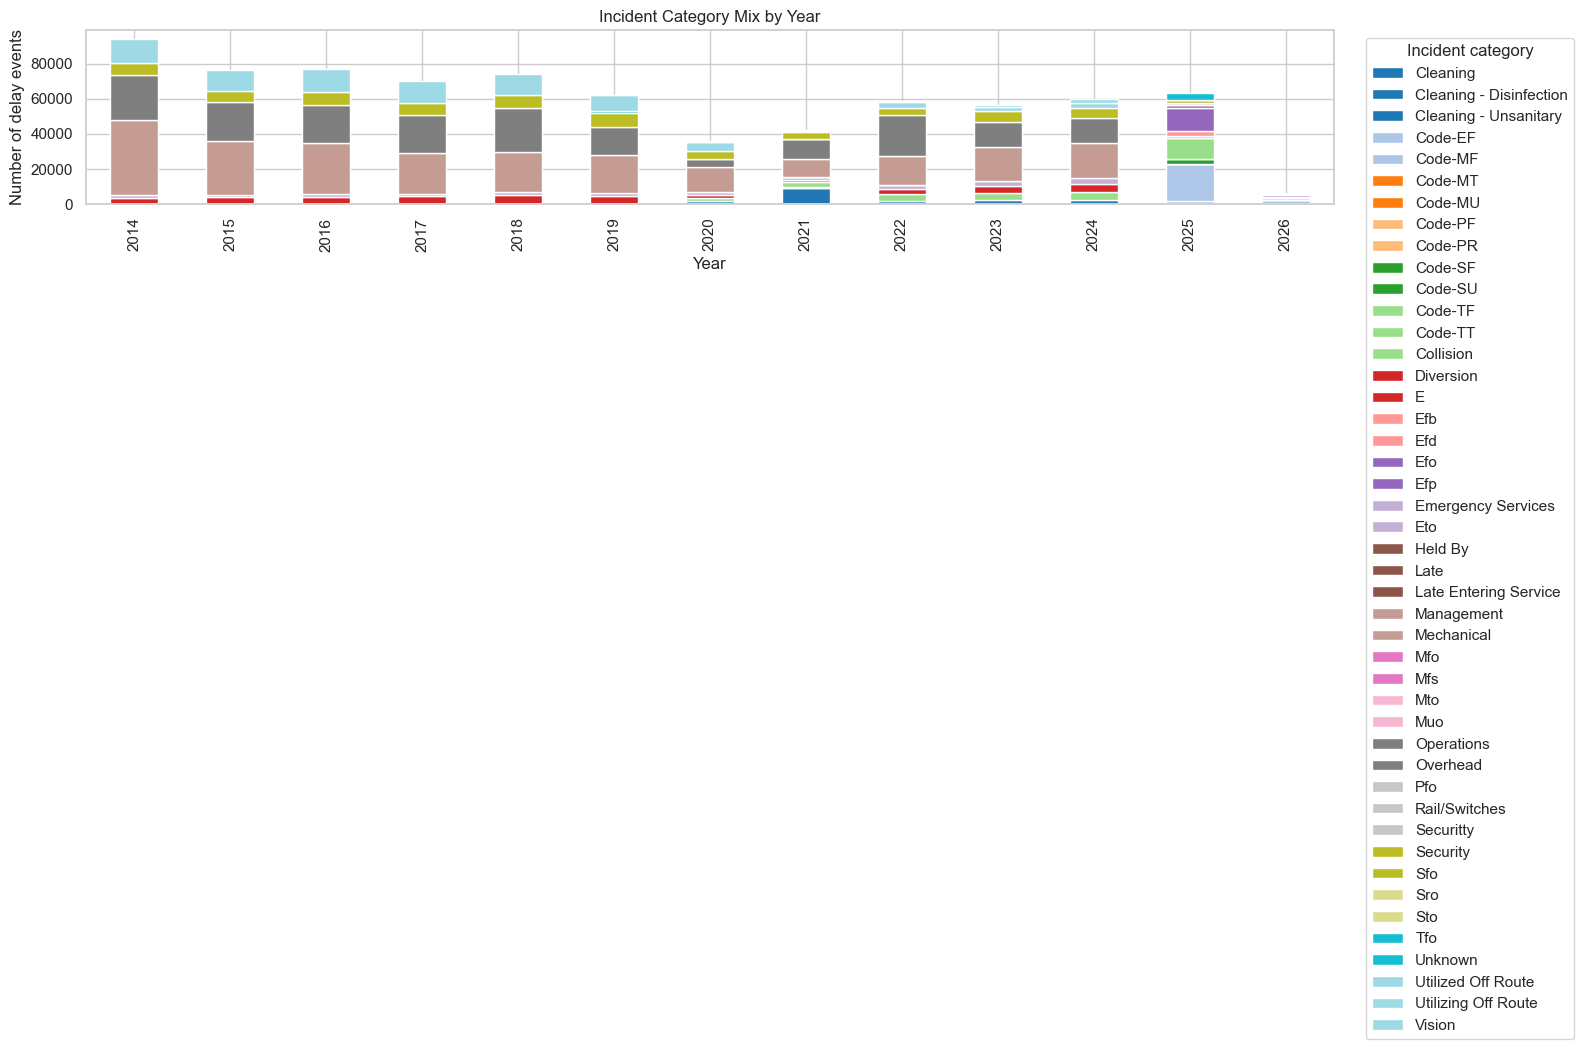

In [9]:
category_by_year = (
    df.groupby(['year', 'incident_category'], as_index=False)
      .agg(events=('incident_category', 'size'), total_delay=('min_delay', 'sum'))
)

category_pivot = category_by_year.pivot(index='year', columns='incident_category', values='events').fillna(0)
display(category_by_year.head(20))

category_pivot.plot(kind='bar', stacked=True, figsize=(16, 7), colormap='tab20')
plt.title('Incident Category Mix by Year')
plt.xlabel('Year')
plt.ylabel('Number of delay events')
plt.legend(title='Incident category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [10]:
top_routes = (
    df.groupby('route', as_index=False)
      .agg(events=('route', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
      .head(20)
)

top_locations = (
    df.groupby('location', as_index=False)
      .agg(events=('location', 'size'), total_delay=('min_delay', 'sum'), avg_delay=('min_delay', 'mean'))
      .sort_values('total_delay', ascending=False)
      .head(20)
)

display(top_routes)
display(top_locations)


,route,events,total_delay,avg_delay
499,41,10230,457879.0,44.789103
603,52,17805,326177.0,18.328669
365,32,17996,286246.0,15.910511
312,29,18251,248609.0,13.629132
94,121,3086,246289.0,80.093984
19,102,12252,245194.0,20.017471
619,54,14316,225424.0,15.749598
1050,96,9508,218881.0,23.030408
429,35,13313,208795.0,15.689435
446,36,16526,202299.0,12.243479


,location,events,total_delay,avg_delay
119132,West Toronto and Keele,9,246682.0,27409.111111
73086,MSTN,460,200272.0,435.373913
58266,KENNEDY STATION,8436,106986.0,12.683580
73381,Main Station,2357,99675.0,42.288927
73528,Main stn,490,93682.0,192.365503
42515,Entire Route,4877,87254.0,17.894586
59293,KIPLING STATION,5967,80816.0,13.543824
35712,EGLINTON STATION,5279,77646.0,14.708468
86508,PIONEER VILLAGE STATIO,4347,73881.0,16.995859
117037,WILSON STATION,4633,68061.0,14.690481
